In [162]:
%pip install pandas numpy matplotlib seaborn

622298.94s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ==========================================
# 1. DATA INGESTION & SECURE TYPE CASTING
# ==========================================
# Rule: Cast variables exactly once immediately after extraction

data = pd.read_csv("../../data/tracker.csv")
data['Hour'] = pd.to_datetime(data['Test time']).dt.hour
data['Day'] = pd.to_datetime(data['Test time']).dt.date
data['Day name'] = pd.to_datetime(data['Test time']).dt.day_name()
data['Test time'] = pd.to_datetime(data['Test time'])

Finding anomolies in download speed

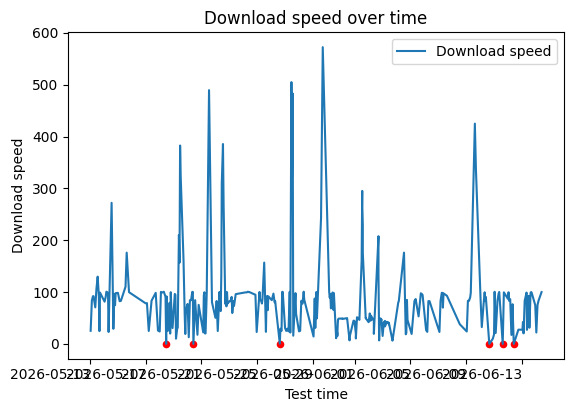

In [43]:
avg_dowload = data['Download speed'].mean()
download_std = data['Download speed'].std()
threshold = avg_dowload - (1 * download_std) #finding threshold for speed


ax = data.plot(x = 'Test time', y = 'Download speed', kind='line')
plt.title("Download speed over time")

data[data['Download speed'] < threshold].plot(kind='scatter', x = 'Test time', y = 'Download speed', color = 'red', ax = ax)

plt.show()

FUNCTIONS FOR PLOTTING

In [ ]:
def generate_download_data(df, metric, filename):

    # ==========================================
    # 2. CANVAS INITIALIZATION (OO Workflow)
    # ==========================================
    # Balanced aspect ratio for a 2x2 grid layout
    fig, axes = plt.subplots(2,2, figsize = (12, 10))
    label = metric.lower()

    # ==========================================
    # 3. PIPELINE VISUALIZATION TARGETING
    # ==========================================

    # DOWNLOAD SPEED DISTRIBUTION
    sns.histplot(data=df, x = metric, ax=axes[0,0])
    axes[0,0].tick_params(labelsize = 10, axis = 'x', rotation = 0)
    axes[0,0].set_xlim(0,150)
    axes[0,0].set_title(f"Distribution of {label}")
    axes[0,0].set_ylabel("Frequency")

    # HOURLY SPEED AVERAGE
    df.groupby(['Hour']).agg(
        avg_download = (metric, 'mean'),

    ).plot(kind='bar', ax= axes[0, 1])
    axes[0,1].tick_params(labelsize = 7, axis = 'x', rotation = 0)
    axes[0,1].set_title(f"{metric} per hour")
    axes[0,1].set_ylabel("Mbps")

    # DAILY SPEED AVERAGE
    df.groupby('Day')[metric].mean().plot(kind = 'line', ax = axes[1,0])
    axes[1,0].tick_params(labelsize = 7, axis = 'x', rotation = 30)
    axes[1,0].set_title(f"Average {label} per day")
    axes[1,0].set_ylabel("Mbps")

    # WEEKLY COMPARED TO HOURLY HEATMAP
    data_heatmap = df.groupby(['Day name', 'Hour'])[metric].mean().unstack()

    sns.heatmap( cmap= 'coolwarm', ax = axes[1,1], data = data_heatmap)
    axes[1,1].tick_params(labelsize = 7, axis = 'y', rotation = 0)
    axes[1,1].tick_params(labelsize = 7, axis = 'x', rotation = 0)
    axes[1,1].set_title("Weekly network performance heatmap")

    # TITLE CREATION
    fig.suptitle(f"{metric} data", fontsize = 16, fontweight = 'bold')
    fig.tight_layout(w_pad=(3.0))

    fig.savefig(f"{filename}")
    print(f"Data png succesfully created called {filename}.")

def finding_anomolies(df, metric):
    avg_dowload = df[metric].mean()
    download_std = df[metric].std()
    threshold = avg_dowload - (1 * download_std) #finding threshold for speed


    ax = data.plot(x = 'Test time', y = metric, kind='line')
    plt.title(f"{metric} over time")

    df[df[metric] < threshold].plot(kind='scatter', x = 'Test time', y = metric, color = 'red', ax = ax)

    plt.show()

Data png succesfully created called Dowload data.


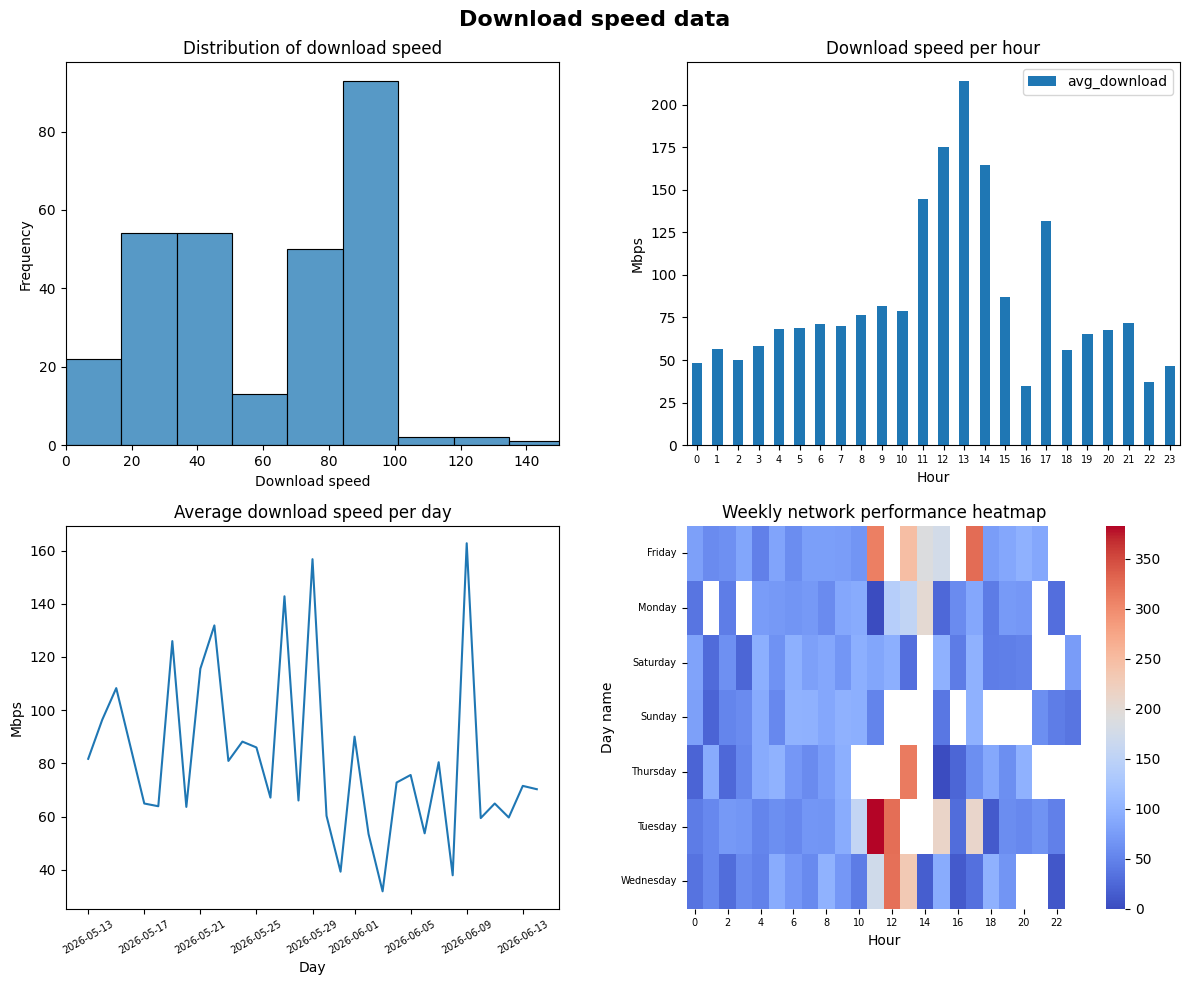

In [37]:
generate_download_data(data, 'Download speed', 'Dowload data')

Data png succesfully created called Upload data.


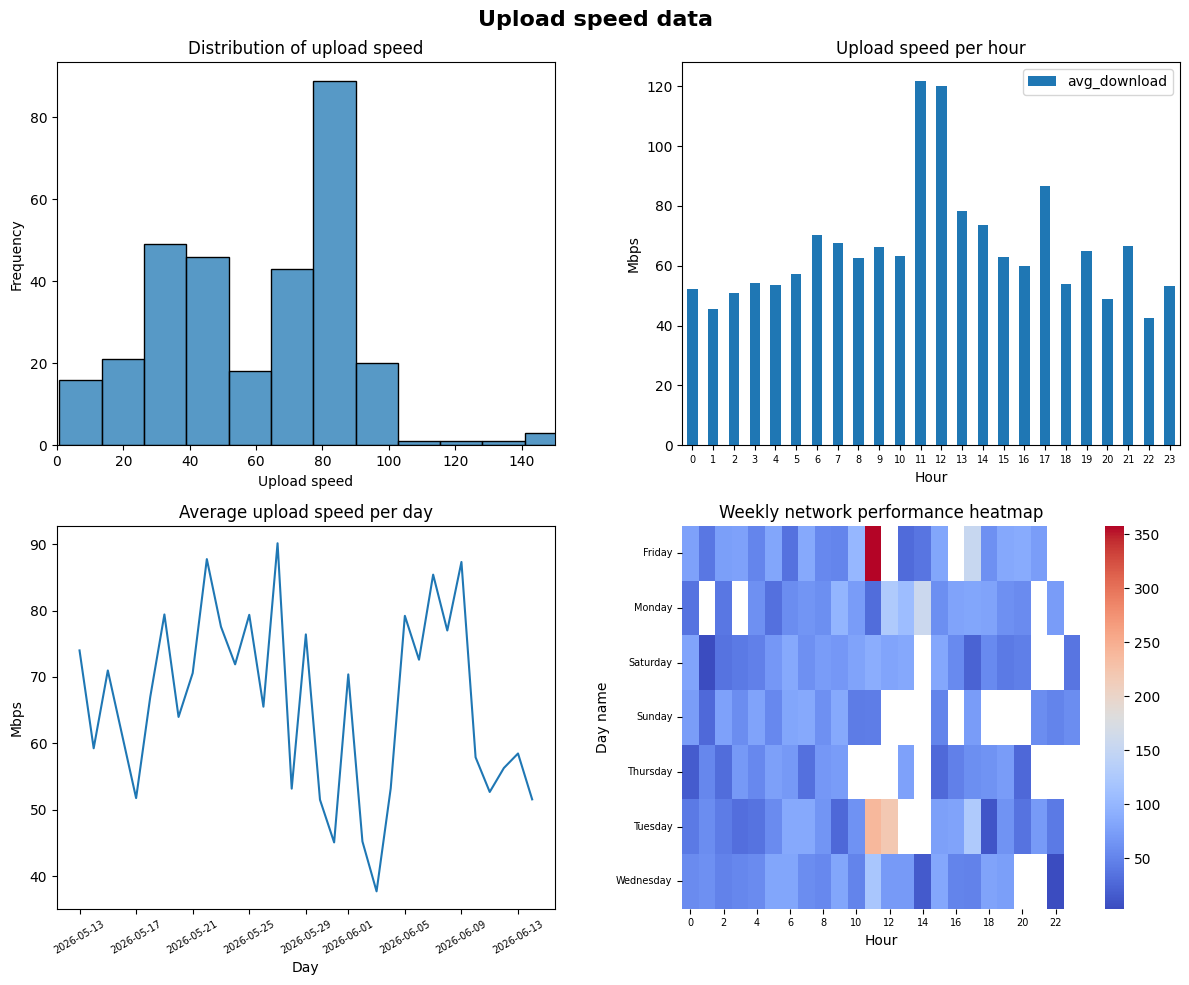

In [39]:
generate_download_data(data, 'Upload speed', 'Upload data')

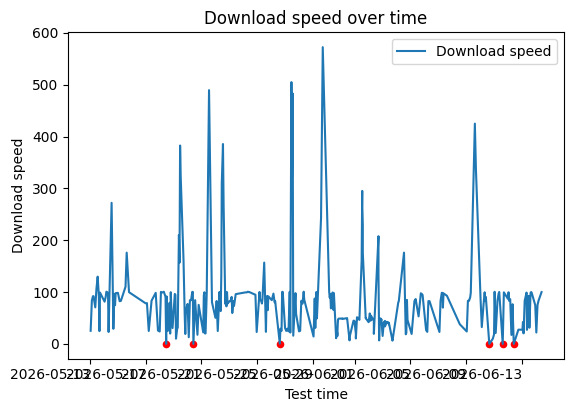

In [42]:
finding_anomolies(data, 'Download speed')

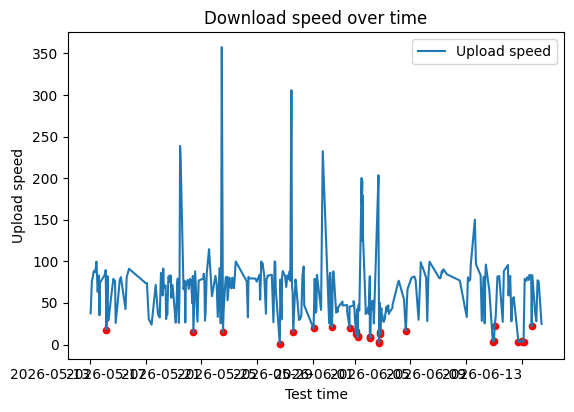

In [44]:
finding_anomolies(data, 'Upload speed')